In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)


def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE")


df = load_data(DATA_PATH)
df.head()

,CPI,EXR,M2b,BRNT,RSV
DATE,,,,,
2003-01-01,49.718237,96.76790,629492.928632,30.808696,2.180175e+09
2003-02-01,49.166690,96.86147,635737.068991,32.662500,2.231537e+09
2003-03-01,48.031996,96.93052,643063.430052,30.168095,2.185916e+09
2003-04-01,47.648499,96.98083,648591.184385,25.035000,2.401949e+09
2003-05-01,48.783192,97.21280,651250.316110,25.714545,2.370521e+09


In [2]:
from statsmodels.tsa.stattools import adfuller, kpss


def adf_test(series: pd.Series) -> pd.Series:
    """Run ADF test on a single series using constant specification."""
    result = adfuller(series.dropna(), regression="c", autolag="AIC")
    return pd.Series({
        "ADF Statistic": result[0], "p-value": result[1], "Lags Used": result[2],
        "Critical Value (5%)": result[4]["5%"], "Stationary": result[1] < 0.05,
    })


def kpss_test(series: pd.Series, regression: str = "c") -> pd.Series:
    """Run KPSS test on a single series. Use 'ct' for raw/trending data, 'c' for differenced data."""
    result = kpss(series.dropna(), regression=regression, nlags="auto")
    return pd.Series({
        "KPSS Statistic": result[0], "p-value": result[1], "Lags Used": result[2],
        "Critical Value (5%)": result[3]["5%"], "Stationary": result[1] >= 0.05,
    })


def run_stationarity_tests(df: pd.DataFrame, kpss_regression: str = "c", label: str = "") -> None:
    """Run ADF and KPSS on every numeric column, display side by side."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    adf_df = pd.DataFrame({col: adf_test(df[col]) for col in numeric_cols}).T
    kpss_df = pd.DataFrame({col: kpss_test(df[col], kpss_regression) for col in numeric_cols}).T

    print(f"\n=== {label} ADF TEST RESULTS ===")
    display(adf_df)
    print(f"\n=== {label} KPSS TEST RESULTS ===")
    display(kpss_df)


run_stationarity_tests(df, kpss_regression="ct", label="RAW DATA")



=== RAW DATA ADF TEST RESULTS ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarn

,ADF Statistic,p-value,Lags Used,Critical Value (5%),Stationary
CPI,-0.37986,0.913407,5,-2.872386,False
EXR,-0.545998,0.882724,2,-2.872265,False
M2b,2.387775,0.999004,15,-2.872809,False
BRNT,-3.059557,0.029695,1,-2.872225,True
RSV,-2.037968,0.270177,8,-2.872509,False



=== RAW DATA KPSS TEST RESULTS ===


,KPSS Statistic,p-value,Lags Used,Critical Value (5%),Stationary
CPI,0.365145,0.01,10,0.146,False
EXR,0.439782,0.01,10,0.146,False
M2b,0.635354,0.01,10,0.146,False
BRNT,0.248662,0.01,10,0.146,False
RSV,0.405333,0.01,10,0.146,False


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_deseasonalized = pd.DataFrame(index=df.index)

for col in ["CPI", "M2b"]:
    decomp = seasonal_decompose(df[col].dropna(), model="multiplicative", period=12)
    df_deseasonalized[col] = df[col] / decomp.seasonal

for col in ["EXR", "RSV", "BRNT"]:
    decomp = seasonal_decompose(df[col].dropna(), model="additive", period=12)
    df_deseasonalized[col] = df[col] - decomp.seasonal

df_final = pd.DataFrame(index=df.index)
df_final["CPI"] = np.log(df_deseasonalized["CPI"]).diff()
df_final["M2b"] = np.log(df_deseasonalized["M2b"]).diff().diff()
for col in ["EXR", "RSV", "BRNT"]:
    df_final[col] = df_deseasonalized[col].diff()

run_stationarity_tests(df_final, kpss_regression="c", label="TRANSFORMED DATA")


=== TRANSFORMED DATA ADF TEST RESULTS ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2258944519.py:15: InterpolationWarn

,ADF Statistic,p-value,Lags Used,Critical Value (5%),Stationary
CPI,-6.906152,0.0,1,-2.872265,True
M2b,-7.852956,0.0,11,-2.872721,True
EXR,-8.962951,0.0,1,-2.872265,True
RSV,-6.944626,0.0,3,-2.872345,True
BRNT,-11.416813,0.0,0,-2.872225,True



=== TRANSFORMED DATA KPSS TEST RESULTS ===


,KPSS Statistic,p-value,Lags Used,Critical Value (5%),Stationary
CPI,0.067374,0.1,8,0.463,True
M2b,0.024887,0.1,11,0.463,True
EXR,0.119488,0.1,6,0.463,True
RSV,0.081658,0.1,0,0.463,True
BRNT,0.081521,0.1,4,0.463,True


In [4]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch


def diagnose_residuals(residuals: pd.Series, lags: int = 12) -> pd.DataFrame:
    """
    Ljung-Box (autocorrelation) and Engle's ARCH (heteroskedasticity) diagnostics.
    NOTE: run here on the transformed series itself, as a stationarity/whiteness
    sanity check on the input data -- not on residuals from a fitted model.
    """
    clean_res = residuals.dropna()
    lb_p = acorr_ljungbox(clean_res, lags=[lags], return_df=True)["lb_pvalue"].iloc[0]
    arch_p = het_arch(clean_res, nlags=lags)[1]

    return pd.DataFrame({
        "Test Type": ["Ljung-Box (Autocorrelation)", "Engle ARCH (Heteroskedasticity)"],
        "p-value": [lb_p, arch_p],
        "Assumption Valid": [lb_p >= 0.05, arch_p >= 0.05],
        "Status": [
            "No Serial Correlation" if lb_p >= 0.05 else "Autocorrelated Resid",
            "Homoskedastic" if arch_p >= 0.05 else "Heteroskedastic/ARCH Effects",
        ],
    }).set_index("Test Type")


for col in ["CPI", "EXR"]:
    print(f"\nDiagnostics for {col} transformed series:")
    display(diagnose_residuals(df_final[col], lags=12))


Diagnostics for CPI transformed series:


,p-value,Assumption Valid,Status
Test Type,,,
Ljung-Box (Autocorrelation),2.216755e-38,False,Autocorrelated Resid
Engle ARCH (Heteroskedasticity),1.333476e-21,False,Heteroskedastic/ARCH Effects



Diagnostics for EXR transformed series:


,p-value,Assumption Valid,Status
Test Type,,,
Ljung-Box (Autocorrelation),9.991315e-26,False,Autocorrelated Resid
Engle ARCH (Heteroskedasticity),2.494079e-24,False,Heteroskedastic/ARCH Effects


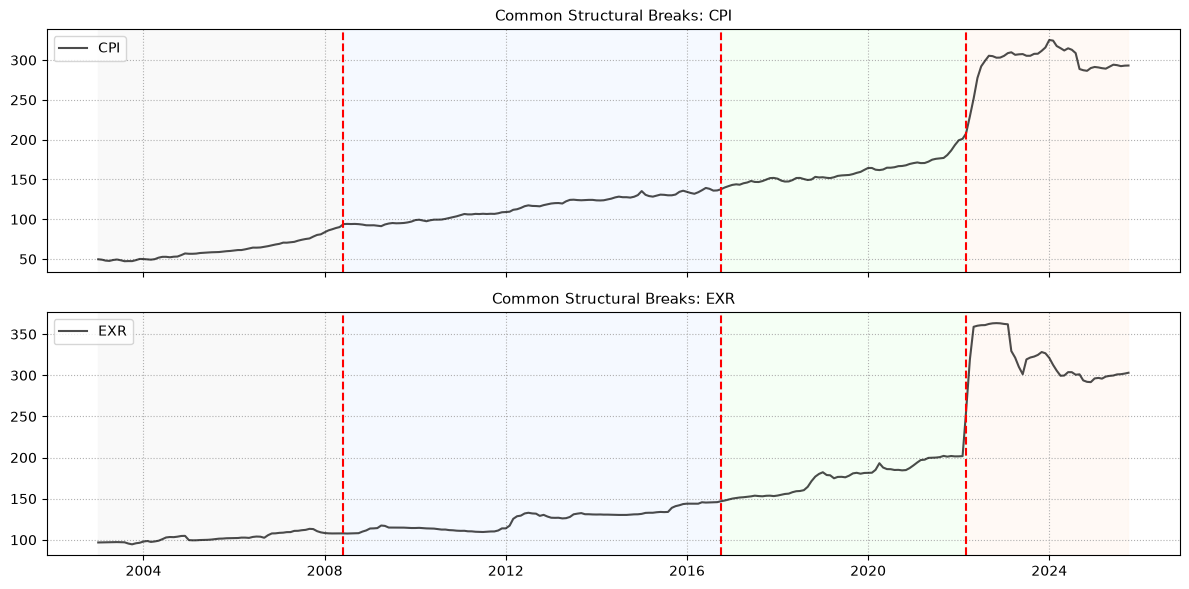

Common Break Dates: ['2008-06-01', '2016-10-01', '2022-03-01']


In [5]:
import matplotlib.pyplot as plt

try:
    import ruptures as rpt
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ruptures"])
    import ruptures as rpt


def find_common_structural_breaks(df: pd.DataFrame, columns: list, n_breaks: int = 3) -> list:
    """Find n_breaks common structural break points across multiple series via multivariate L2 minimization."""
    clean_df = df[columns].dropna()
    signal = clean_df.values
    time_index = clean_df.index

    algo = rpt.Dynp(model="l2", min_size=2).fit(signal)
    break_indices = algo.predict(n_bkps=n_breaks)
    break_dates = [time_index[min(idx, len(time_index) - 1)] for idx in break_indices[:-1]]

    fig, axes = plt.subplots(len(columns), 1, figsize=(12, 3 * len(columns)), sharex=True)
    colors = ["#f2f2f2", "#e6f2ff", "#e6ffe6", "#fff2e6"]
    all_edges = [time_index[0]] + break_dates + [time_index[-1]]

    for ax, col in zip(np.atleast_1d(axes), columns):
        ax.plot(time_index, clean_df[col], color="black", alpha=0.7, label=col)
        ax.set_title(f"Common Structural Breaks: {col}", fontsize=11)
        for bk_date in break_dates:
            ax.axvline(bk_date, color="red", linestyle="--", linewidth=1.5)
        for i in range(len(all_edges) - 1):
            ax.axvspan(all_edges[i], all_edges[i + 1], color=colors[i % len(colors)], alpha=0.4)
        ax.legend(loc="upper left")
        ax.grid(True, linestyle=":")

    plt.tight_layout()
    plt.show()
    return break_dates


common_breaks = find_common_structural_breaks(df, ["CPI", "EXR"])
print(f"Common Break Dates: {[d.strftime('%Y-%m-%d') for d in common_breaks]}")

In [6]:
def select_n_breaks(df: pd.DataFrame, columns: list, max_breaks: int = 5) -> pd.DataFrame:
    """Score candidate break counts via penalized cost, to justify n_breaks rather than assume it."""
    clean_df = df[columns].dropna()
    signal = clean_df.values
    n = len(signal)

    rows = []
    for k in range(1, max_breaks + 1):
        algo = rpt.Dynp(model="l2", min_size=2).fit(signal)
        break_idx = algo.predict(n_bkps=k)
        cost = algo.cost.sum_of_costs(break_idx)
        n_params = k * signal.shape[1]
        bic = n * np.log(cost / n) + n_params * np.log(n)
        rows.append({"n_breaks": k, "cost": cost, "BIC": bic})

    result = pd.DataFrame(rows).set_index("n_breaks")
    result["is_min_BIC"] = result["BIC"] == result["BIC"].min()
    return result


bic_table = select_n_breaks(df, ["CPI", "EXR"], max_breaks=5)
display(bic_table.round(2))
print(f"BIC-optimal n_breaks: {bic_table['BIC'].idxmin()}")

,cost,BIC,is_min_BIC
n_breaks,,,
1,624000.27,2129.46,False
2,226712.56,1863.27,False
3,130857.95,1723.91,False
4,90341.05,1633.62,False
5,73952.10,1590.00,True


BIC-optimal n_breaks: 5


In [7]:
bic_table_transformed = select_n_breaks(df_final.dropna(), ["CPI", "EXR"], max_breaks=10)
display(bic_table_transformed.round(2))
print(f"BIC-optimal n_breaks (transformed): {bic_table_transformed['BIC'].idxmin()}")

,cost,BIC,is_min_BIC
n_breaks,,,
1,10552.15,1006.26,False
2,8177.87,948.14,False
3,7719.58,943.67,True
4,7550.62,948.86,False
5,7382.90,953.96,False
6,7344.82,963.77,False
7,7203.75,969.70,False
8,7180.28,980.03,False
9,7117.69,988.86,False


BIC-optimal n_breaks (transformed): 3


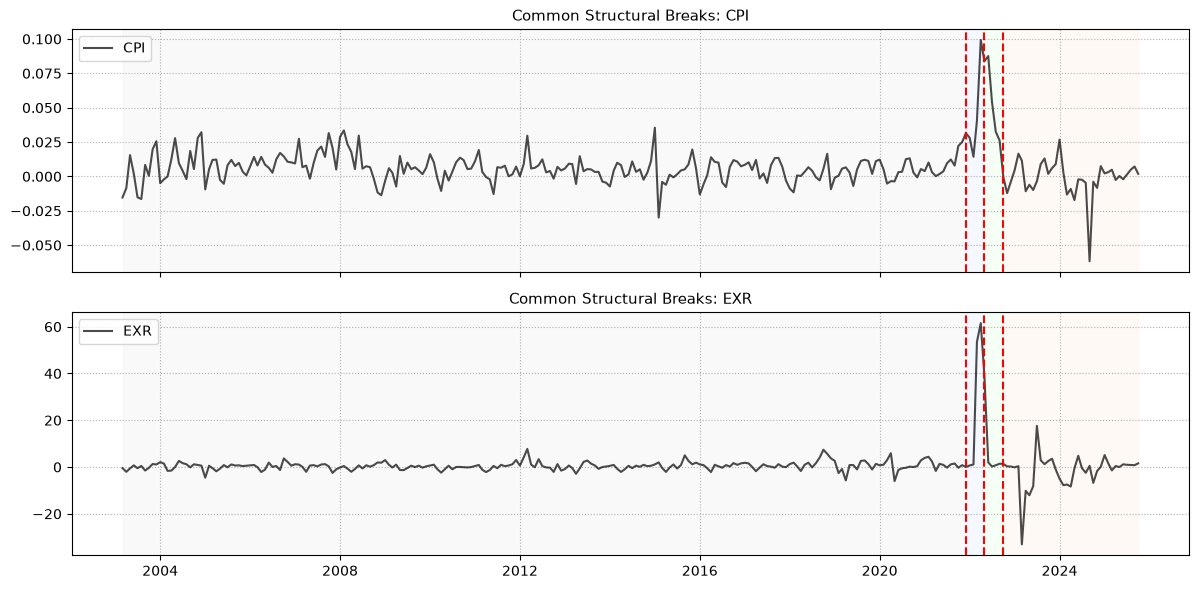

Raw-level breaks (n=3):          ['2008-06', '2016-10', '2022-03']
Transformed-series breaks (n=3): ['2021-12', '2022-05', '2022-10']


In [8]:
transformed_breaks_at_3 = find_common_structural_breaks(df_final.dropna(), ["CPI", "EXR"], n_breaks=3)
print(f"Raw-level breaks (n=3):          {[d.strftime('%Y-%m') for d in common_breaks]}")
print(f"Transformed-series breaks (n=3): {[d.strftime('%Y-%m') for d in transformed_breaks_at_3]}")

In [6]:
os.makedirs("../results", exist_ok=True)
pd.DataFrame({"break_date": [d.strftime("%Y-%m-%d") for d in common_breaks]}).to_csv(
    "../results/structural_breaks.csv", index=False
)